In [6]:
%pip install ultralytics pyyaml

Note: you may need to restart the kernel to use updated packages.


In [3]:
import os
import shutil #untuk merekayasa file
import random
import yaml #untuk membaca dataset yaml
from pathlib import Path #untuk membuka file didalam folder

In [5]:
SOURCE_IMAGE = "D:/UPH/Skripsi/code/dataset/project-8-at-2026-08-29-22-04-174ba896/images"
SOURCE_LABELS = "D:/UPH/Skripsi/code/dataset/project-8-at-2026-08-29-22-04-174ba896/labels"

OUTPUT_DIR = "yolo_dataset"

In [6]:
CLASS_NAMES = {
    0: "Matang",
    1: "Mentah",
    2: "Setengah Matang"
}

In [7]:
image_extensions = {".jpg", ".jpeg", ".png", ".bmp"}

pairs = []
missing_labels = []

source_image_dir = Path(SOURCE_IMAGE)
source_label_dir = Path(SOURCE_LABELS)

for img_path in source_image_dir.iterdir():
    if img_path.suffix.lower() in image_extensions:
        label_path = source_label_dir / f"{img_path.stem}.txt"

        if label_path.exists():
            pairs.append((img_path, label_path))
        else:
            missing_labels.append(img_path.name)

print("Jumlah gambar:", len(list(source_image_dir.iterdir())))
print("Jumlah pasangan image + txt:", len(pairs))
print("Jumlah gambar tanpa label:", len(missing_labels))

Jumlah gambar: 172
Jumlah pasangan image + txt: 172
Jumlah gambar tanpa label: 0


In [8]:
if len(pairs) > 0:
    example_image, example_label = pairs[0]

    print("Image:", example_image)
    print("Label:", example_label)

    with open(example_label, "r") as f:
        lines = f.readlines()

    print("Isi label:")
    for line in lines:
        print(line.strip())

else:
    print("Tidak ada pasangan image dan label yang ditemukan")

Image: D:\UPH\Skripsi\code\dataset\project-8-at-2026-08-29-22-04-174ba896\images\00763d47-DSC_0754_JPG.rf.d02fe903eb2f148982248196e3d9c27a.jpg
Label: D:\UPH\Skripsi\code\dataset\project-8-at-2026-08-29-22-04-174ba896\labels\00763d47-DSC_0754_JPG.rf.d02fe903eb2f148982248196e3d9c27a.txt
Isi label:
1 0.09593584081323715 0.305347434759002 0.14381841696343295 0.305347434759002 0.14381841696343295 0.35792438112000124 0.09593584081323715 0.35792438112000124


In [9]:
found_class_ids = set()

for img_path, label_path in pairs:
    with open(label_path, "r") as f:
        for line in f:
            line = line.strip()
            if line:
                class_id = int(line.split()[0])
                found_class_ids.add(class_id)

print("Class ID yang ditemukan di dataset:", sorted(found_class_ids))
print("Class ID yang Anda definisikan:", sorted(CLASS_NAMES.keys()))

Class ID yang ditemukan di dataset: [0, 1, 2]
Class ID yang Anda definisikan: [0, 1, 2]


In [10]:
random.seed(42)
random.shuffle(pairs)

total_data = len(pairs)

train_end = int(total_data * 0.7)
val_end = int(total_data * 0.9)

train_pairs = pairs[:train_end]
val_pairs = pairs[train_end:val_end]
test_pairs = pairs[val_end:]

print("Train:", len(train_pairs))
print("Val:", len(val_pairs))
print("Test:", len(test_pairs))

Train: 120
Val: 34
Test: 18


In [11]:
splits = {
    "train": train_pairs,
    "val": val_pairs,
    "test": test_pairs
}


for split_name, split_pairs in splits.items():
    image_out_dir = Path(OUTPUT_DIR) / "images" / split_name
    label_out_dir = Path(OUTPUT_DIR) / "labels" / split_name

    image_out_dir.mkdir(parents=True, exist_ok=True)
    label_out_dir.mkdir(parents=True, exist_ok=True)

    for img_path, label_path in split_pairs:
        shutil.copy(img_path, image_out_dir / img_path.name)
        shutil.copy(label_path, label_out_dir / label_path.name)

print("Dataset YOLO berhasil dibuat di folder:", OUTPUT_DIR)

Dataset YOLO berhasil dibuat di folder: yolo_dataset


In [12]:
dataset_config = {
    "path": str(Path(OUTPUT_DIR).resolve()),
    "train": "images/train",
    "val": "images/val",
    "test": "images/test",
    "names": CLASS_NAMES
}

with open("dataset.yaml", "w") as f:
    yaml.safe_dump(dataset_config, f, sort_keys=False)

print("File dataset.yaml berhasil dibuat.")

File dataset.yaml berhasil dibuat.


In [1]:
from ultralytics import YOLO
model = YOLO("yolov8n.pt")

In [3]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import matplotlib
matplotlib.use('Agg')

from ultralytics import YOLO
import torch

torch.cuda.empty_cache()

model = YOLO("yolov8s.pt")

results = model.train(
    data="dataset.yaml",
    epochs=24,
    imgsz=640,
    batch=4,
    device=0,
    workers=0,
    plots=False,
    cache=False,
    verbose=True
)

New https://pypi.org/project/ultralytics/8.4.135 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.133  Python-3.10.19 torch-2.7.1+cu118 CUDA:0 (NVIDIA GeForce RTX 3050 Laptop GPU, 4096MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=24, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=t

In [7]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

from ultralytics import YOLO

model = YOLO("runs/detect/train-11/weights/best.pt")

metrics = model.val(
    data="dataset.yaml",
    split="test",
    plots=True,
    workers=0,
)

print("mAP50 test :", metrics.box.map50)
print("mAP50-95   :", metrics.box.map)

Ultralytics 8.4.133  Python-3.10.19 torch-2.7.1+cu118 CUDA:0 (NVIDIA GeForce RTX 3050 Laptop GPU, 4096MiB)


Model summary (fused): 73 layers, 11,126,745 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 1273.7166.0 MB/s, size: 1156.4 KB)
val: Scanning D:\UPH\Skripsi\code\yolo_dataset\labels\test.cache... 18 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 18/18  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 1.5it/s 1.3s3.6s
                   all         18        108      0.929      0.814      0.911      0.692
                Matang         11         14      0.965      0.929      0.943      0.731
                Mentah         18         81      0.938      0.746      0.934      0.627
       Setengah Matang          8         13      0.885      0.769      0.856      0.718
Speed: 2.3ms preprocess, 15.9ms inference, 0.0ms loss, 0.9ms postprocess per image
Results saved to D:\UPH\Skripsi\code\runs\detect\val-2
mAP50 test : 0.9109659719204469
mAP50-95   : 0.6919377477891723


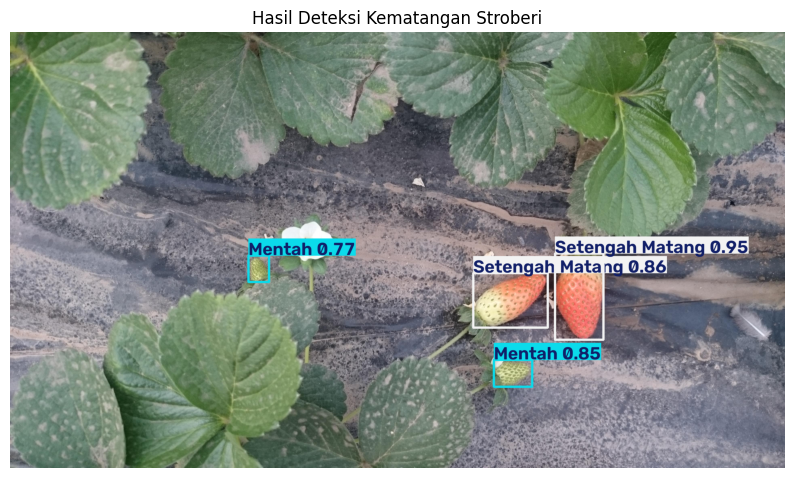

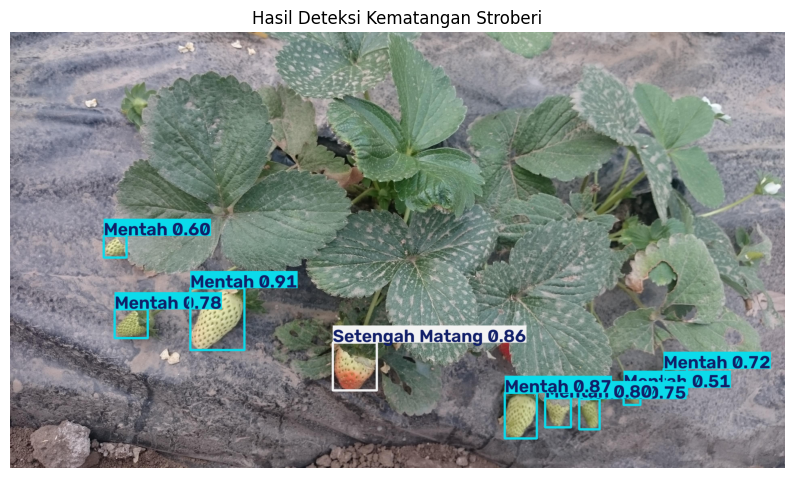

In [11]:
%matplotlib inline
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO

# 1. Load model terbaik
BEST_MODEL = r"D:/UPH/Skripsi/code/runs/detect/train-11/weights/best.pt"
model = YOLO(BEST_MODEL)

# 2. Tentukan path gambar yang mau dites (GANTI DENGAN NAMA FILE GAMBAR ANDA)
TEST_IMG = r"D:/UPH/Skripsi/code/yolo_dataset/images/test/ecd72da6-DSC_1272_JPG.rf.b1a44b971fe5a66e68842c6196923a7d.jpg"

# 3. Lakukan prediksi
results = model.predict(source=TEST_IMG, conf=0.45, verbose=False)

# 4. Format gambar agar warna sesuai (BGR ke RGB)
annotated = cv2.cvtColor(results[0].plot(), cv2.COLOR_BGR2RGB)

# 5. Tampilkan gambar di notebook
plt.figure(figsize=(10, 8))
plt.imshow(annotated)
plt.axis("off")
plt.title("Hasil Deteksi Kematangan Stroberi")
plt.show()